In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/thedevastator/higher-education-predictors-of-student-retention/dataset.csv


In [2]:
# =============================================================================
# SHAP Analysis with LightGBM & XGBoost on Kaggle
# Dataset: UCI Adult Income (many features, ~48k observations)
# =============================================================================

In [3]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report

import lightgbm as lgb
import xgboost as xgb
import shap

shap.initjs()          # enables JS-based interactive plots in notebooks

In [4]:
# # ── 1. Load Data (UCI Adult Income via OpenML / Kaggle-bundled sklearn) ───────
# # The Adult dataset has 48 842 rows and 14 features (mix of numeric & categorical)
# # sklearn ships it natively — no extra Kaggle dataset download needed.
# from sklearn.datasets import fetch_openml

# print("Loading dataset …")
# adult = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
# df = adult.frame.copy()
# print(f"Shape: {df.shape}")
# print(df.head(3))

In [5]:
# # ── 2. Preprocessing ──────────────────────────────────────────────────────────
# # Target: income  ('>50K' → 1,  '<=50K' → 0)
# df["target"] = (df["class"].str.strip() == ">50K").astype(int)
# df.drop(columns=["class"], inplace=True)

# # Drop rows with any missing value for simplicity
# df.dropna(inplace=True)
# print(f"Shape after dropna: {df.shape}")

# # Encode all object columns as integer codes
# cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
# le = LabelEncoder()
# for col in cat_cols:
#     df[col] = le.fit_transform(df[col].astype(str))

# feature_names = [c for c in df.columns if (c != "target" and c not in cat_cols)]
# X = df[feature_names].astype(float)
# y = df["target"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

In [6]:
# ── 1. Load Data

df = pd.read_csv('/kaggle/input/datasets/thedevastator/higher-education-predictors-of-student-retention/dataset.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [8]:
# ── 2. Preprocessing ──────────────────────────────────────────────────────────
df["Target"] = (df["Target"].str.strip() == "Graduate").astype(int)


# Drop rows with any missing value for simplicity
df.dropna(inplace=True)
print(f"Shape after dropna: {df.shape}")

# Encode all object columns as integer codes
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

feature_names = [c for c in df.columns if (c != "Target")]
X = df[feature_names].astype(float)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Shape after dropna: (4424, 35)
Train: (3539, 34)  |  Test: (885, 34)


In [9]:
# ── 3. Train LightGBM ─────────────────────────────────────────────────────────
print("\n── Training LightGBM ──")
lgb_params = dict(
    objective="binary",
    metric="auc",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
lgb_auc = roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1])
print(f"LightGBM  AUC: {lgb_auc:.4f}")
print(classification_report(y_test, lgb_model.predict(X_test)))


── Training LightGBM ──
LightGBM  AUC: 0.9060
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       443
           1       0.79      0.88      0.84       442

    accuracy                           0.83       885
   macro avg       0.83      0.83      0.83       885
weighted avg       0.83      0.83      0.83       885



In [10]:
# ── 4. Train XGBoost ──────────────────────────────────────────────────────────
print("\n── Training XGBoost ──")
xgb_params = dict(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
print(f"XGBoost   AUC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_model.predict(X_test)))


── Training XGBoost ──
[0]	validation_0-auc:0.87374
[100]	validation_0-auc:0.91050
[200]	validation_0-auc:0.90981
[300]	validation_0-auc:0.90930
[400]	validation_0-auc:0.90761
[499]	validation_0-auc:0.90550
XGBoost   AUC: 0.9055
              precision    recall  f1-score   support

           0       0.86      0.79      0.82       443
           1       0.80      0.87      0.84       442

    accuracy                           0.83       885
   macro avg       0.83      0.83      0.83       885
weighted avg       0.83      0.83      0.83       885




Computing SHAP values for LightGBM …
Computing SHAP values for XGBoost …

── SHAP Summary Plots ──


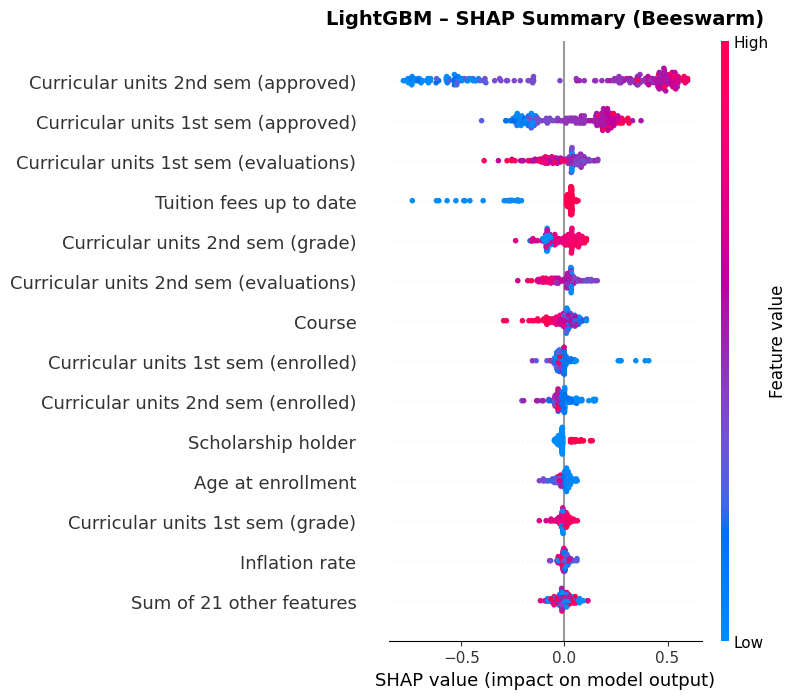

[Saved] shap_summary_lightgbm.png


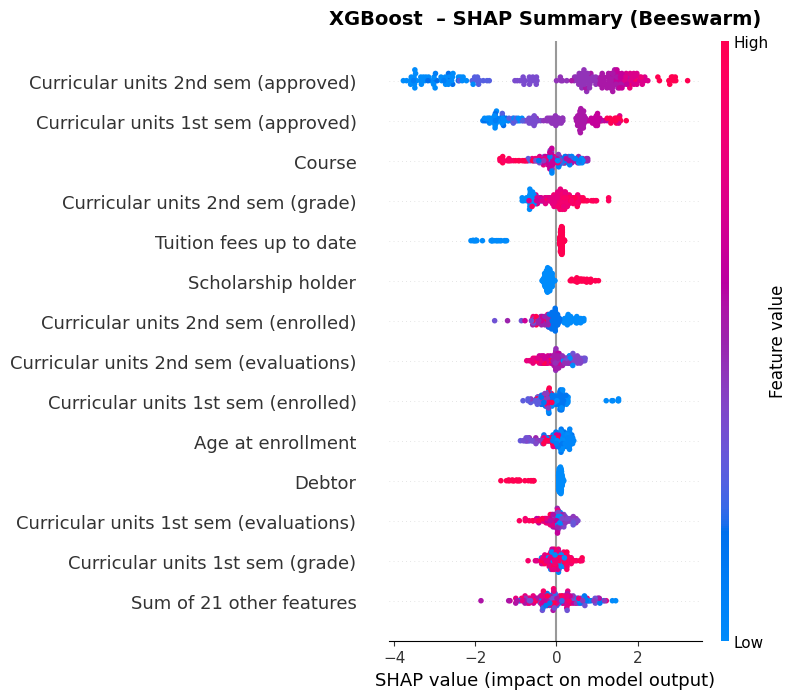

[Saved] shap_summary_xgboost.png

── Full Feature Importance (Graph + Table) ──


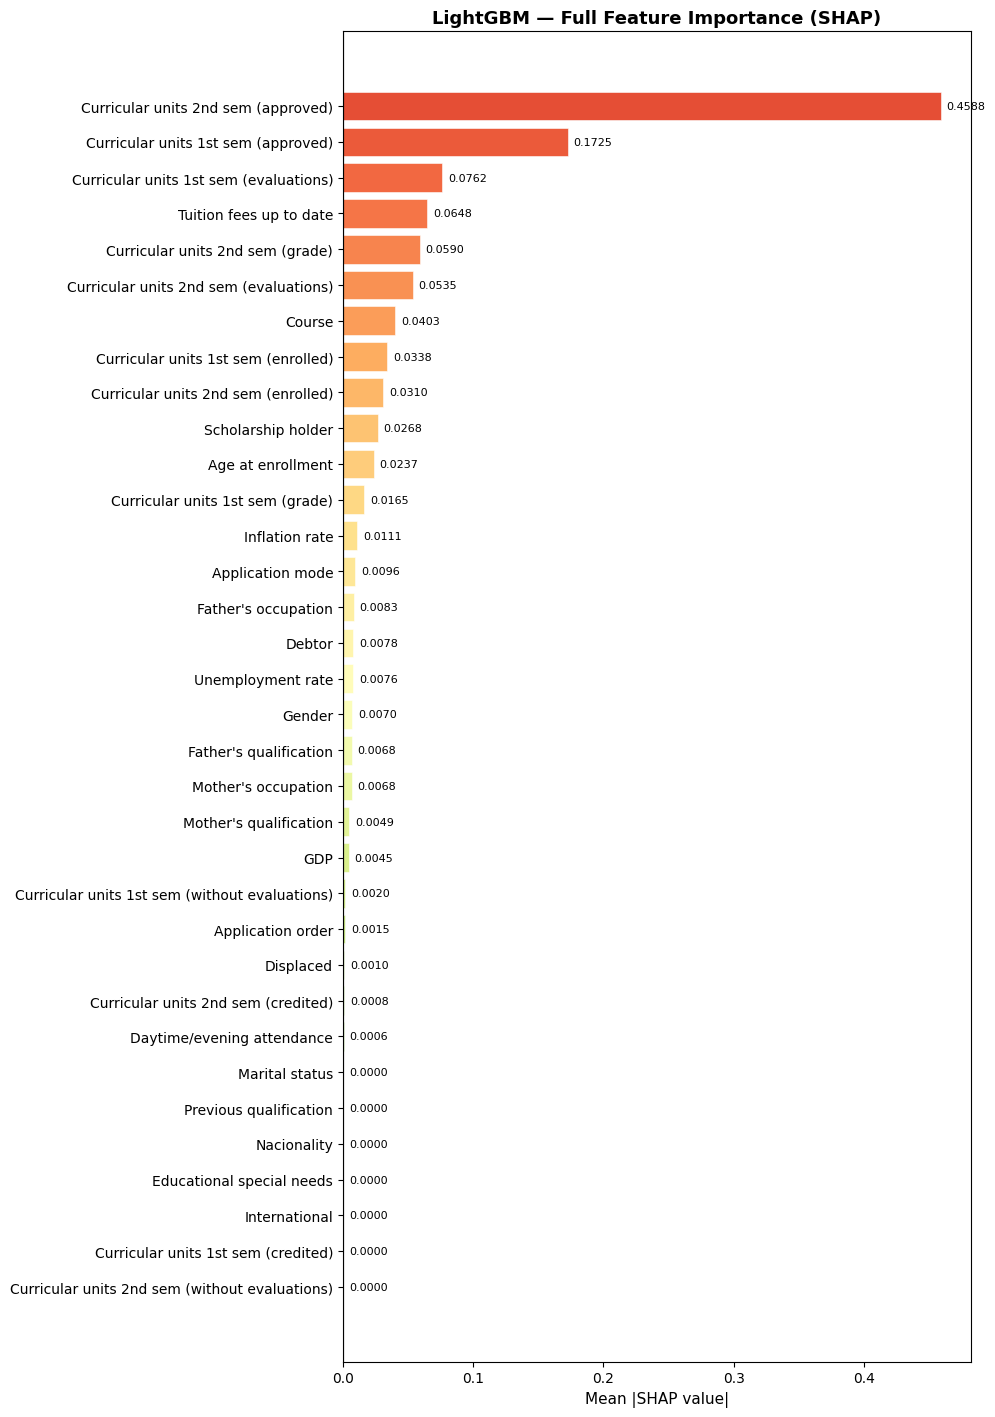

[Saved] shap_importance_lightgbm.png

LightGBM – Full SHAP Feature Importance Table
                                             feature  mean_abs_shap
rank                                                               
1                Curricular units 2nd sem (approved)       0.458809
2                Curricular units 1st sem (approved)       0.172479
3             Curricular units 1st sem (evaluations)       0.076215
4                            Tuition fees up to date       0.064775
5                   Curricular units 2nd sem (grade)       0.058982
6             Curricular units 2nd sem (evaluations)       0.053484
7                                             Course       0.040331
8                Curricular units 1st sem (enrolled)       0.033760
9                Curricular units 2nd sem (enrolled)       0.031039
10                                Scholarship holder       0.026781
11                                 Age at enrollment       0.023675
12                  Curricular u

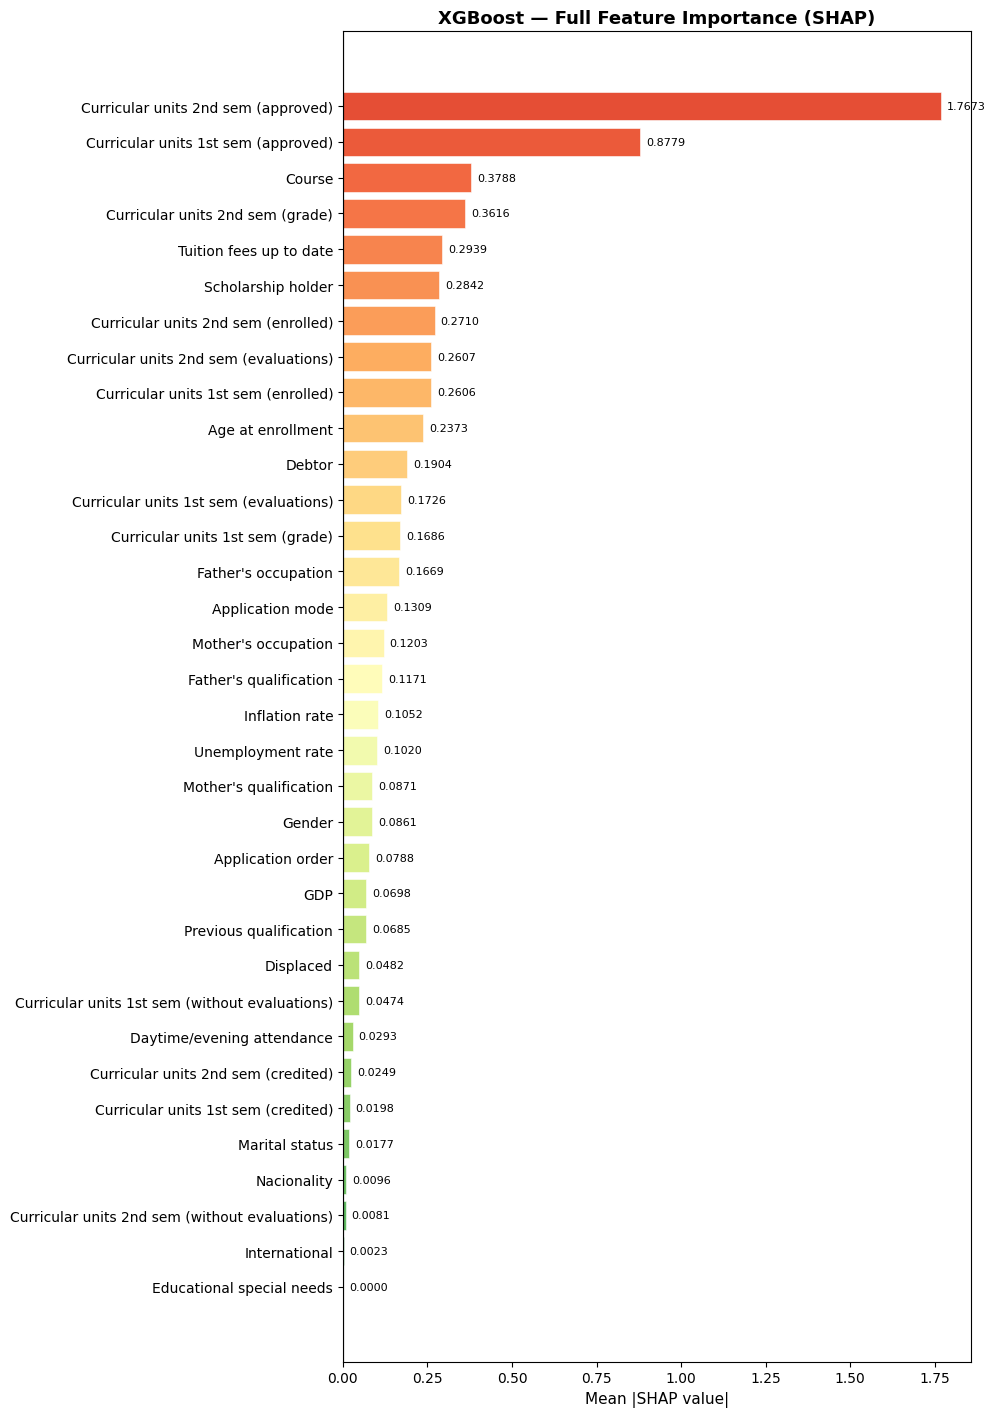

[Saved] shap_importance_xgboost.png

XGBoost – Full SHAP Feature Importance Table
                                             feature  mean_abs_shap
rank                                                               
1                Curricular units 2nd sem (approved)       1.767336
2                Curricular units 1st sem (approved)       0.877949
3                                             Course       0.378831
4                   Curricular units 2nd sem (grade)       0.361576
5                            Tuition fees up to date       0.293949
6                                 Scholarship holder       0.284159
7                Curricular units 2nd sem (enrolled)       0.271045
8             Curricular units 2nd sem (evaluations)       0.260702
9                Curricular units 1st sem (enrolled)       0.260628
10                                 Age at enrollment       0.237270
11                                            Debtor       0.190369
12            Curricular units 1st

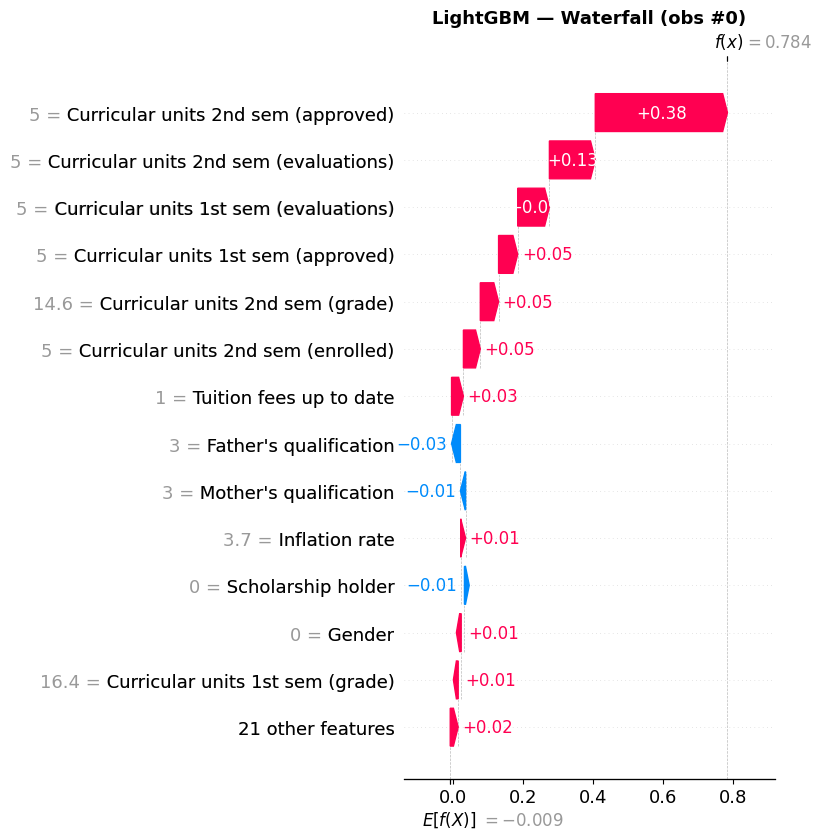

[Saved] shap_waterfall_lightgbm_0.png


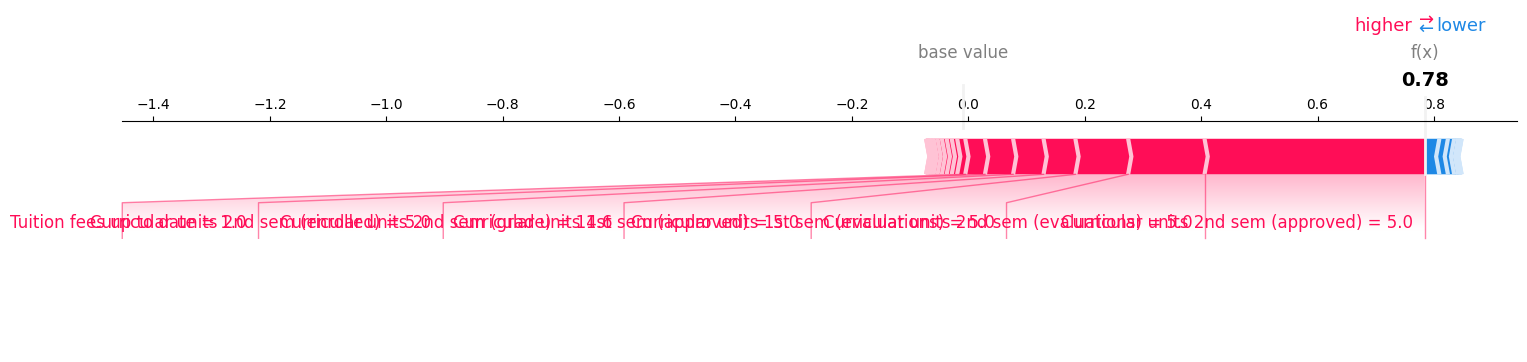

[Saved] shap_force_lightgbm_0.png

Per-feature SHAP contributions for observation #0:
  Base value (log-odds): -0.0090
  Sum of SHAP + base   : 0.7840
                                             feature  feature_value  shap_contribution
rank                                                                                  
1                Curricular units 2nd sem (approved)            5.0           0.378136
2             Curricular units 2nd sem (evaluations)            5.0           0.131250
3             Curricular units 1st sem (evaluations)            5.0           0.090652
4                Curricular units 1st sem (approved)            5.0           0.054706
5                   Curricular units 2nd sem (grade)           14.6           0.052306
6                Curricular units 2nd sem (enrolled)            5.0           0.048300
7                            Tuition fees up to date            1.0           0.033908
8                             Father's qualification            3.

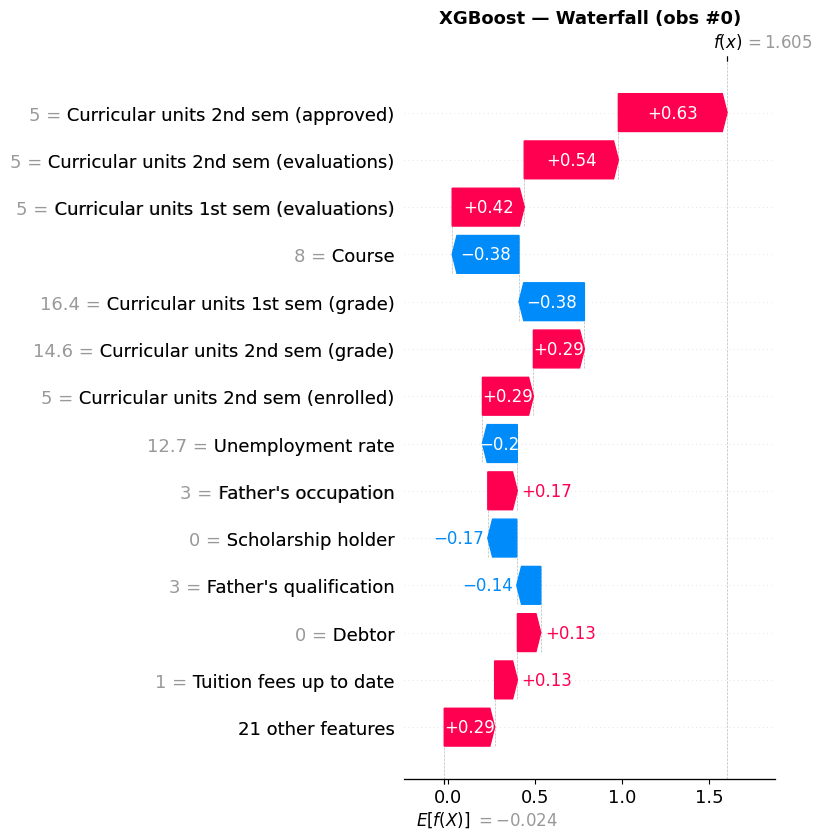

[Saved] shap_waterfall_xgboost_0.png


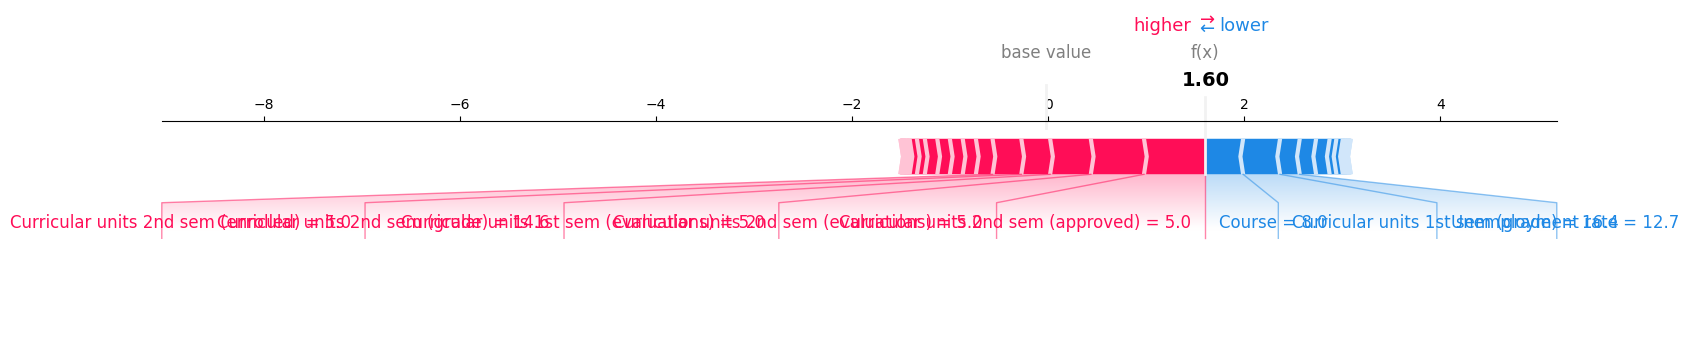

[Saved] shap_force_xgboost_0.png

Per-feature SHAP contributions for observation #0:
  Base value (log-odds): -0.0244
  Sum of SHAP + base   : 1.6048
                                             feature  feature_value  shap_contribution
rank                                                                                  
1                Curricular units 2nd sem (approved)            5.0           0.626119
2             Curricular units 2nd sem (evaluations)            5.0           0.542270
3             Curricular units 1st sem (evaluations)            5.0           0.415030
4                                             Course            8.0          -0.384869
5                   Curricular units 1st sem (grade)           16.4          -0.376606
6                   Curricular units 2nd sem (grade)           14.6           0.293719
7                Curricular units 2nd sem (enrolled)            5.0           0.293509
8                                  Unemployment rate           12.7

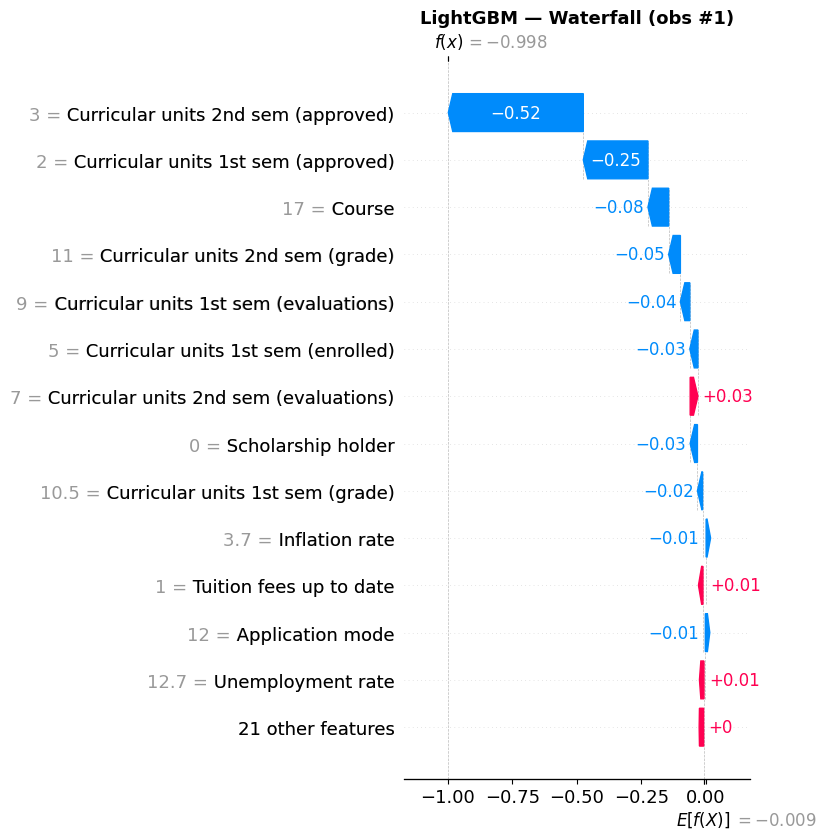

[Saved] shap_waterfall_lightgbm_1.png


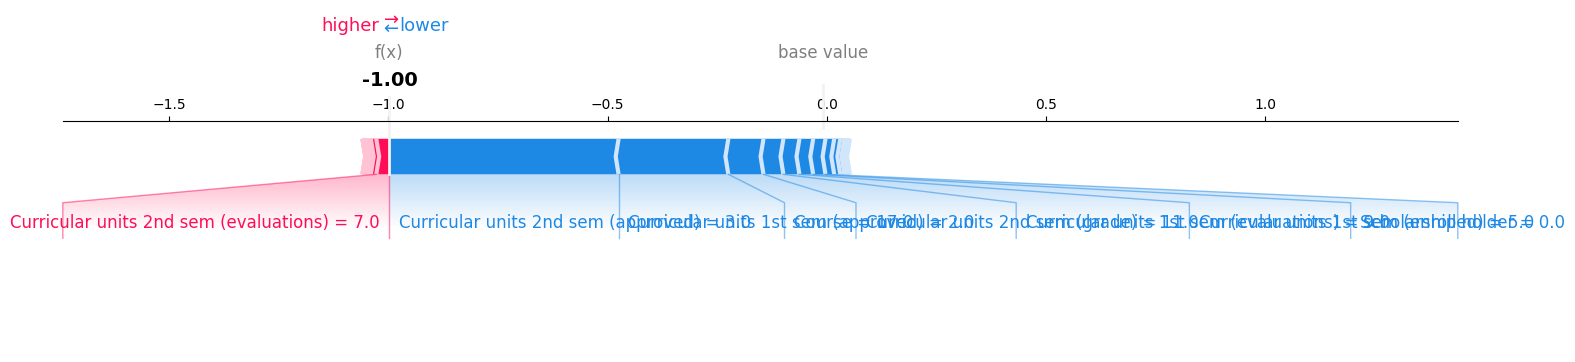

[Saved] shap_force_lightgbm_1.png

Per-feature SHAP contributions for observation #1:
  Base value (log-odds): -0.0090
  Sum of SHAP + base   : -0.9977
                                             feature  feature_value  shap_contribution
rank                                                                                  
1                Curricular units 2nd sem (approved)            3.0          -0.522766
2                Curricular units 1st sem (approved)            2.0          -0.250334
3                                             Course           17.0          -0.080169
4                   Curricular units 2nd sem (grade)           11.0          -0.045444
5             Curricular units 1st sem (evaluations)            9.0          -0.036547
6                Curricular units 1st sem (enrolled)            5.0          -0.031386
7             Curricular units 2nd sem (evaluations)            7.0           0.030040
8                                 Scholarship holder            0

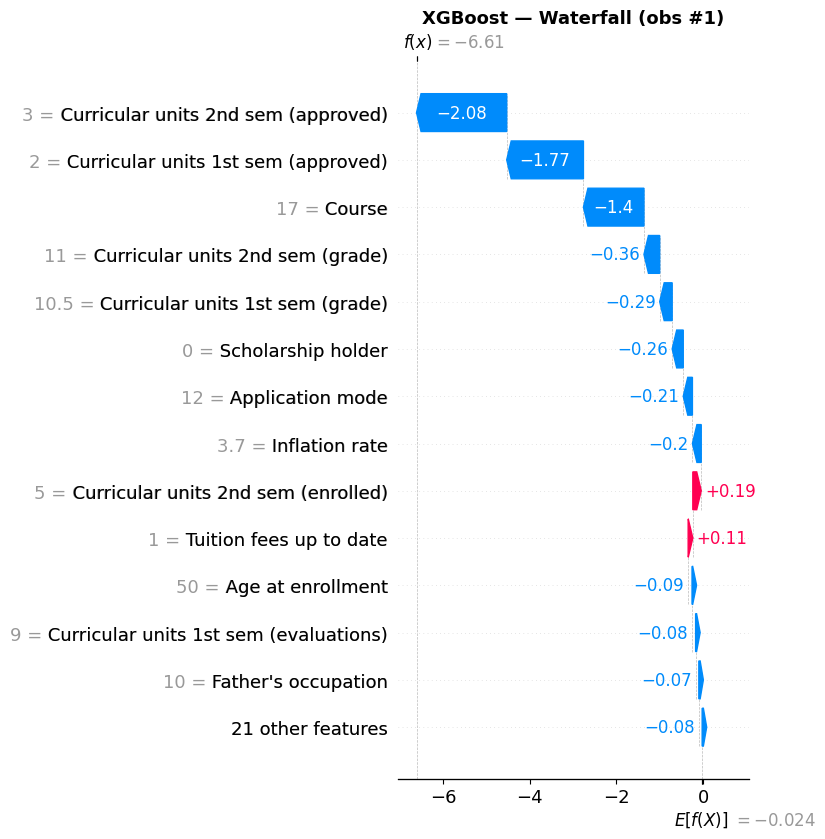

[Saved] shap_waterfall_xgboost_1.png


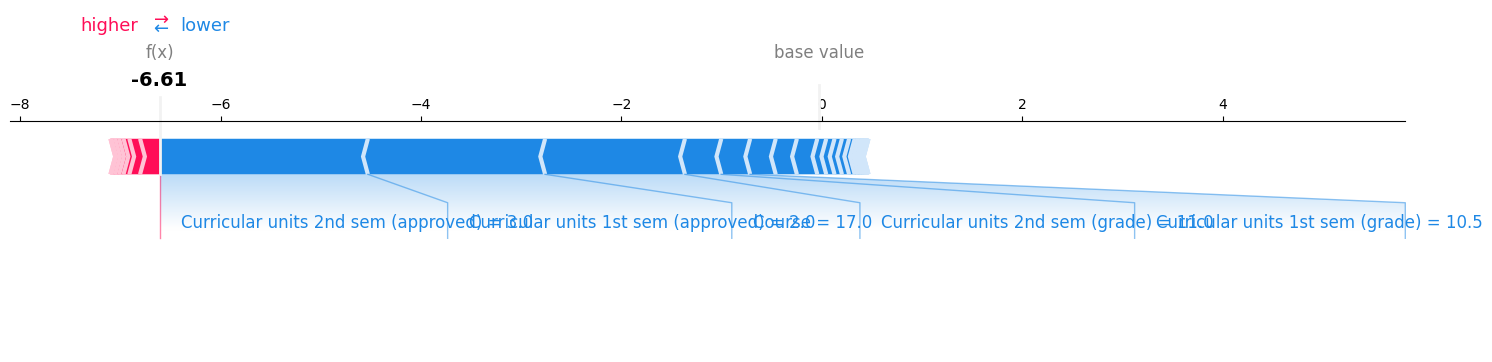

[Saved] shap_force_xgboost_1.png

Per-feature SHAP contributions for observation #1:
  Base value (log-odds): -0.0244
  Sum of SHAP + base   : -6.6099
                                             feature  feature_value  shap_contribution
rank                                                                                  
1                Curricular units 2nd sem (approved)            3.0          -2.079028
2                Curricular units 1st sem (approved)            2.0          -1.769090
3                                             Course           17.0          -1.395579
4                   Curricular units 2nd sem (grade)           11.0          -0.362358
5                   Curricular units 1st sem (grade)           10.5          -0.288335
6                                 Scholarship holder            0.0          -0.255409
7                                   Application mode           12.0          -0.211089
8                                     Inflation rate            3.

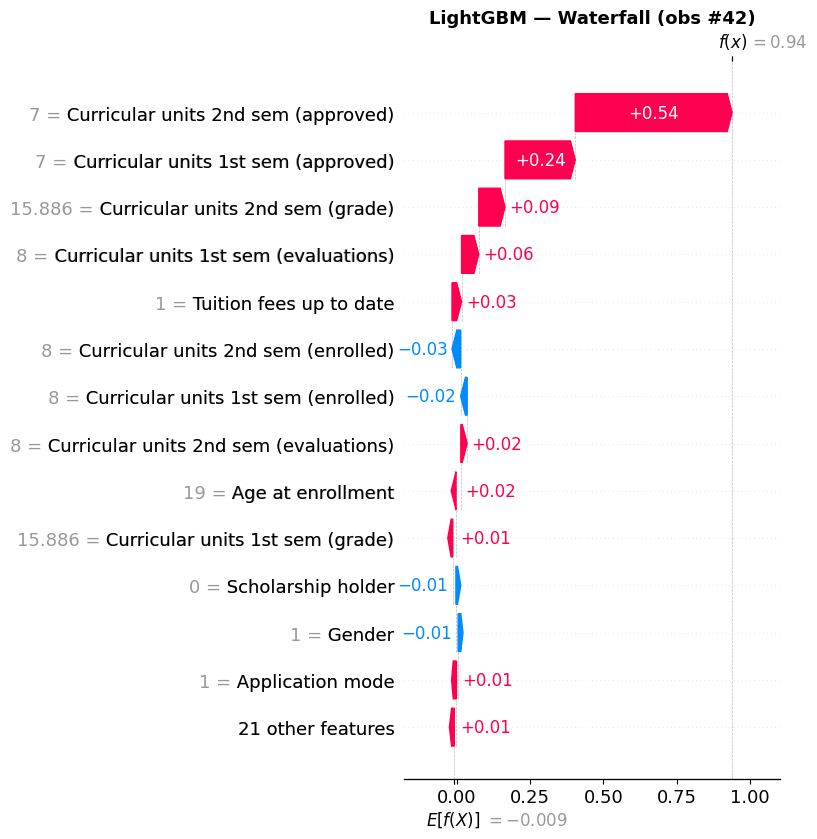

[Saved] shap_waterfall_lightgbm_42.png


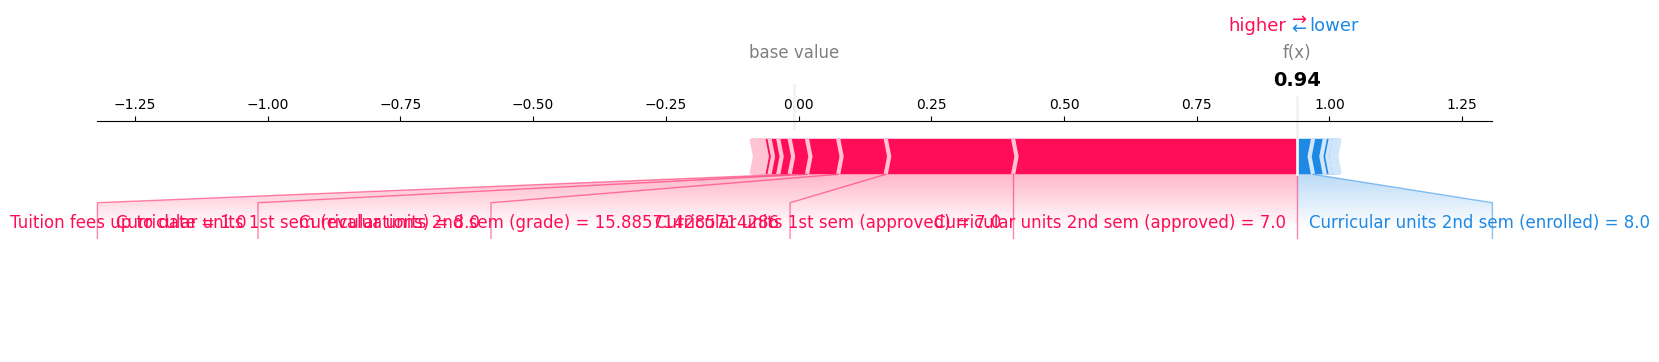

[Saved] shap_force_lightgbm_42.png

Per-feature SHAP contributions for observation #42:
  Base value (log-odds): -0.0090
  Sum of SHAP + base   : 0.9398
                                             feature  feature_value  shap_contribution
rank                                                                                  
1                Curricular units 2nd sem (approved)       7.000000       5.355922e-01
2                Curricular units 1st sem (approved)       7.000000       2.399442e-01
3                   Curricular units 2nd sem (grade)      15.885714       8.960418e-02
4             Curricular units 1st sem (evaluations)       8.000000       5.877142e-02
5                            Tuition fees up to date       1.000000       3.264957e-02
6                Curricular units 2nd sem (enrolled)       8.000000      -2.950242e-02
7                Curricular units 1st sem (enrolled)       8.000000      -2.218981e-02
8             Curricular units 2nd sem (evaluations)       8.000

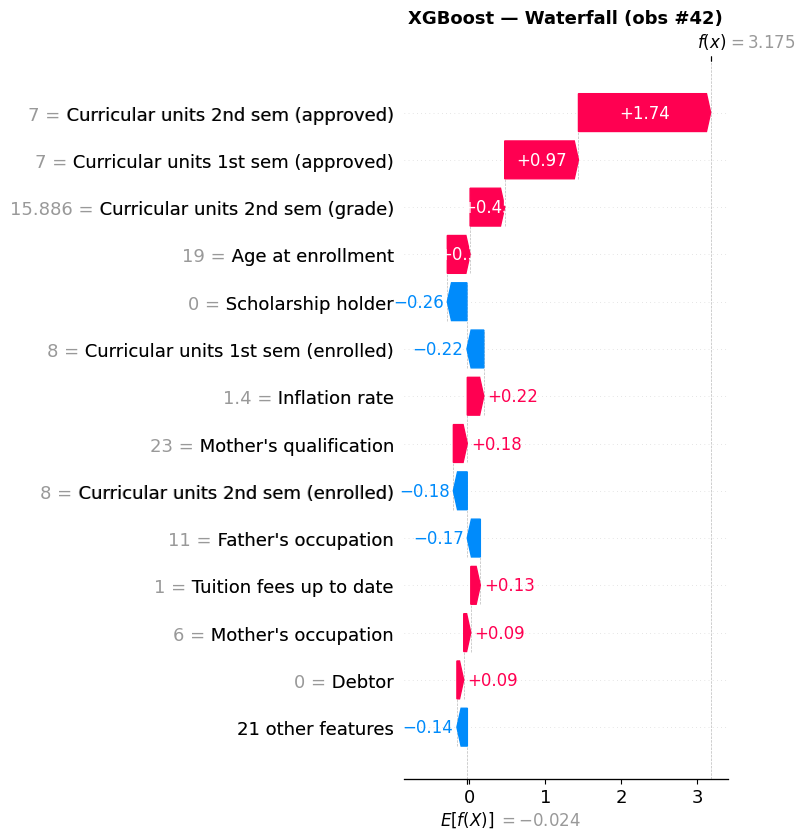

[Saved] shap_waterfall_xgboost_42.png


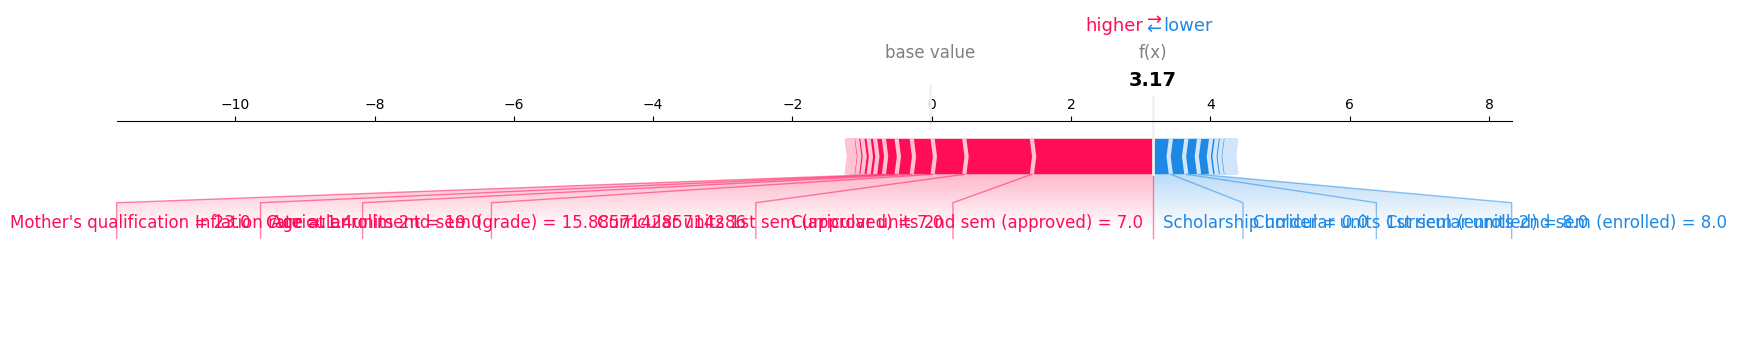

[Saved] shap_force_xgboost_42.png

Per-feature SHAP contributions for observation #42:
  Base value (log-odds): -0.0244
  Sum of SHAP + base   : 3.1746
                                             feature  feature_value  shap_contribution
rank                                                                                  
1                Curricular units 2nd sem (approved)       7.000000           1.738418
2                Curricular units 1st sem (approved)       7.000000           0.969670
3                   Curricular units 2nd sem (grade)      15.885714           0.454916
4                                  Age at enrollment      19.000000           0.299578
5                                 Scholarship holder       0.000000          -0.257928
6                Curricular units 1st sem (enrolled)       8.000000          -0.221913
7                                     Inflation rate       1.400000           0.217225
8                             Mother's qualification      23.0000

In [11]:
# ── 5. SHAP Explainers ────────────────────────────────────────────────────────
# Use a subsample of test set for speed (SHAP on full dataset is slow)
SAMPLE_N = 200
idx_sample = np.random.RandomState(42).choice(len(X_test), SAMPLE_N, replace=False)
X_shap = X_test.iloc[idx_sample].reset_index(drop=True)
 
print("\nComputing SHAP values for LightGBM …")
explainer_lgb = shap.TreeExplainer(lgb_model)
# Use the legacy shap_values() call which always returns a plain ndarray.
# For binary classification it returns a list of 2 arrays [class0, class1];
# we keep class-1. We then rebuild a lightweight Explanation object so the
# rest of the plotting code (beeswarm, waterfall, force) works unchanged.
_sv_lgb_raw = explainer_lgb.shap_values(X_shap)          # list of 2 arrays
_sv_lgb_arr = _sv_lgb_raw[1] if isinstance(_sv_lgb_raw, list) else _sv_lgb_raw
_base_lgb    = explainer_lgb.expected_value
_base_lgb    = _base_lgb[1] if isinstance(_base_lgb, (list, np.ndarray)) else _base_lgb
sv_lgb = shap.Explanation(
    values      = _sv_lgb_arr,
    base_values = np.full(len(X_shap), _base_lgb),
    data        = X_shap.values,
    feature_names = feature_names,
)
 
print("Computing SHAP values for XGBoost …")
explainer_xgb = shap.TreeExplainer(xgb_model)
_sv_xgb_raw = explainer_xgb.shap_values(X_shap)
_sv_xgb_arr = _sv_xgb_raw[1] if isinstance(_sv_xgb_raw, list) else _sv_xgb_raw
_base_xgb    = explainer_xgb.expected_value
_base_xgb    = _base_xgb[1] if isinstance(_base_xgb, (list, np.ndarray)) else _base_xgb
sv_xgb = shap.Explanation(
    values      = _sv_xgb_arr,
    base_values = np.full(len(X_shap), _base_xgb),
    data        = X_shap.values,
    feature_names = feature_names,
)
 
# =============================================================================
# SHAP VISUALISATION – SECTION A: Summary Plot (top-N features, how they affect)
# =============================================================================
 
def plot_summary(sv, title, top_n=14):
    """Beeswarm summary plot showing direction + magnitude of top features."""
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.beeswarm(sv, max_display=top_n, show=False)
    plt.title(title, fontsize=14, fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(f"shap_summary_{title.split()[0].lower()}.png", dpi=150)
    plt.show()
    print(f"[Saved] shap_summary_{title.split()[0].lower()}.png")
 
print("\n── SHAP Summary Plots ──")
plot_summary(sv_lgb, "LightGBM – SHAP Summary (Beeswarm)")
plot_summary(sv_xgb, "XGBoost  – SHAP Summary (Beeswarm)")
 
# =============================================================================
# SHAP VISUALISATION – SECTION B: Full Feature Importance — Graph + Table
# =============================================================================
 
def feature_importance_graph_and_table(sv, model_name, feature_names):
    """
    Bar chart of mean |SHAP| for ALL features  +  a tidy DataFrame table.
    """
    vals = sv.values
    # Guard: TreeExplainer sometimes returns 3D (n_samples, n_features, n_classes).
    # Collapse to 2D by taking the positive-class slice so mean(axis=0) gives
    # exactly one value per feature — never fewer rows than features in the CSV.
    if vals.ndim == 3:
        vals = vals[:, :, -1]
    mean_abs_shap = np.abs(vals).mean(axis=0)   # guaranteed shape: (n_features,)
    assert len(mean_abs_shap) == len(feature_names), (
        f"Shape mismatch: {len(mean_abs_shap)} SHAP cols vs {len(feature_names)} features"
    )
    importance_df = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    importance_df.index += 1          # rank starts at 1
    importance_df.index.name = "rank"
 
    # ── Graph ──
    fig, ax = plt.subplots(figsize=(10, max(5, len(feature_names) * 0.42)))
    colors = plt.cm.RdYlGn_r(
        np.linspace(0.15, 0.85, len(feature_names))
    )
    bars = ax.barh(
        importance_df["feature"][::-1],
        importance_df["mean_abs_shap"][::-1],
        color=colors,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set_xlabel("Mean |SHAP value|", fontsize=11)
    ax.set_title(f"{model_name} — Full Feature Importance (SHAP)", fontsize=13, fontweight="bold")
    ax.axvline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars, importance_df["mean_abs_shap"][::-1]):
        ax.text(val + importance_df["mean_abs_shap"].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    fname_graph = f"shap_importance_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fname_graph, dpi=150)
    plt.show()
    print(f"[Saved] {fname_graph}")
 
    # ── Table ──
    print(f"\n{model_name} – Full SHAP Feature Importance Table")
    print("=" * 52)
    print(importance_df.to_string())
    print()
 
    return importance_df
 
print("\n── Full Feature Importance (Graph + Table) ──")
imp_lgb = feature_importance_graph_and_table(sv_lgb, "LightGBM", feature_names)
imp_xgb = feature_importance_graph_and_table(sv_xgb, "XGBoost",  feature_names)
 
# Save tables to CSV as well
imp_lgb.to_csv("shap_importance_lgb.csv")
imp_xgb.to_csv("shap_importance_xgb.csv")
print("[Saved] shap_importance_lgb.csv  &  shap_importance_xgb.csv")
 
# =============================================================================
# SHAP VISUALISATION – SECTION C: Individual Explanation (Waterfall + Force)
# =============================================================================
 
def explain_individual(sv, explainer, model_name, X_shap, idx=0):
    """
    For observation `idx` show:
      1. Waterfall plot  – ranked feature contributions
      2. Force plot      – interactive bar (rendered in notebook)
    """
    print(f"\n── {model_name} – Individual explanation for row index {idx} ──")
 
    # ─ 1. Waterfall plot ─
    fig, _ = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(sv[idx], max_display=14, show=False)
    plt.title(f"{model_name} — Waterfall (obs #{idx})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fname_wf = f"shap_waterfall_{model_name.lower().replace(' ','_')}_{idx}.png"
    plt.savefig(fname_wf, dpi=150)
    plt.show()
    print(f"[Saved] {fname_wf}")
 
    # ─ 2. Force plot (interactive in Kaggle notebook) ─
    # The force plot shows the push/pull of every feature toward or away from the base value.
    force = shap.force_plot(
        base_value=sv.base_values[idx],
        shap_values=sv.values[idx],
        features=X_shap.iloc[idx],
        feature_names=feature_names,
        matplotlib=True,           # set False for interactive JS version in notebook
        show=False,
        figsize=(18, 3),
    )
    fname_fp = f"shap_force_{model_name.lower().replace(' ','_')}_{idx}.png"
    plt.savefig(fname_fp, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Saved] {fname_fp}")
 
    # ─ 3. Per-feature contribution table for this observation ─
    contrib_df = (
        pd.DataFrame({
            "feature":          feature_names,
            "feature_value":    X_shap.iloc[idx].values,
            "shap_contribution": sv.values[idx],
        })
        .sort_values("shap_contribution", key=abs, ascending=False)
        .reset_index(drop=True)
    )
    contrib_df.index += 1
    contrib_df.index.name = "rank"
    print(f"\nPer-feature SHAP contributions for observation #{idx}:")
    print(f"  Base value (log-odds): {sv.base_values[idx]:.4f}")
    print(f"  Sum of SHAP + base   : {sv.base_values[idx] + sv.values[idx].sum():.4f}")
    print(contrib_df.to_string())
    return contrib_df
 
# Explain a few different individuals (indices within X_shap)
INDIVIDUALS = [0, 1, 42]          # ← change to any row indices you like
 
print("\n══════════════════════════════════════════════════════")
print("  SECTION C – Individual-Level SHAP Explanations")
print("══════════════════════════════════════════════════════")
 
for i in INDIVIDUALS:
    contrib_lgb = explain_individual(sv_lgb, explainer_lgb, "LightGBM", X_shap, idx=i)
    contrib_xgb = explain_individual(sv_xgb, explainer_xgb, "XGBoost",  X_shap, idx=i)
 
print("\n✅  All SHAP analyses complete.")
print("   Saved artefacts:")
print("     • shap_summary_lightgbm.png / shap_summary_xgboost.png")
print("     • shap_importance_lightgbm.png / shap_importance_xgboost.png")
print("     • shap_importance_lgb.csv / shap_importance_xgb.csv")
print("     • shap_waterfall_* / shap_force_*  (one pair per individual per model)")